In [1]:
import mysql.connector
import numpy as np
import pandas as pd
import astropy.io.fits as fits
from matplotlib import pyplot as plt
import tiledb
import os

In [2]:
img_file = "./hyb2_tir_20180801_101707_l1.fit"
hdul = fits.open(img_file)
hdul.info()

Filename: ./hyb2_tir_20180801_101707_l1.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      38   (384, 256)   float32   


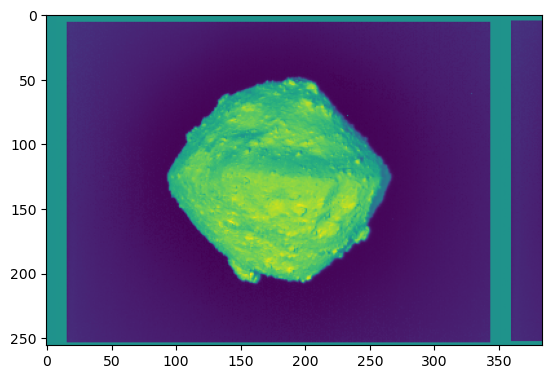

In [3]:
hdu = hdul[0]
data = hdu.data
header = hdu.header
plt.imshow(data)
plt.show()

In [4]:
base_dir = "/Volumes/Transcend/tileDB"
os.makedirs(base_dir, exist_ok=True)
array_uri = os.path.join(base_dir, "fitsTable")


In [5]:
dim_filename = tiledb.Dim(name="filename", domain=None, dtype="ascii")
domain = tiledb.Domain(dim_filename)
attr_pixel = tiledb.Attr(name="pixel", dtype=np.float32,var=True)
attr_height = tiledb.Attr(name="height", dtype=np.int32)
attr_width = tiledb.Attr(name="width", dtype=np.int32)

attrs = [
    attr_pixel, 
    attr_height,
    attr_width,
]

schema = tiledb.ArraySchema(
    domain=domain,
    attrs=attrs,    
    sparse=True
)
if tiledb.array_exists(array_uri):
    tiledb.remove(array_uri)
new_array = tiledb.Array.create(array_uri, schema)






In [6]:
print(new_array)

None


In [7]:
HEIGHT,WIDTH = data.shape
with tiledb.SparseArray(array_uri, mode="w") as array:
    coords = np.array([img_file],dtype=object)
    pixel_var = data.reshape(-1)
    array[coords] = {
        "pixel":pixel_var,
        "height":np.array([HEIGHT],dtype=np.int32),
        "width":np.array([WIDTH],dtype=np.int32),
    }


ValueError: value length (98304) does not match coordinate length (1)